In [137]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Making a Forward Model

## Configure a DM

In [138]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

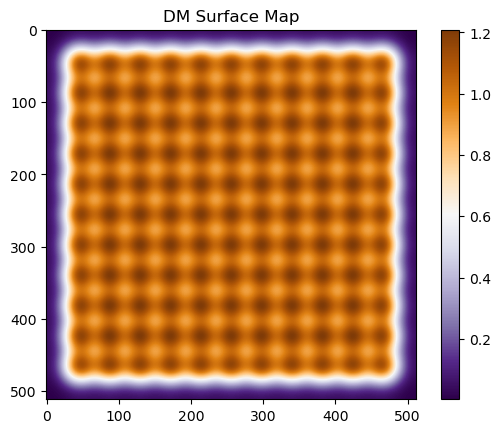

In [139]:
dm.actuators[:] = 1
sfe = dm.render(wfe=False)
plt.title("DM Surface Map")
plt.imshow(sfe, cmap="PuOr_r")
plt.colorbar()

## Configure Wavefront Error

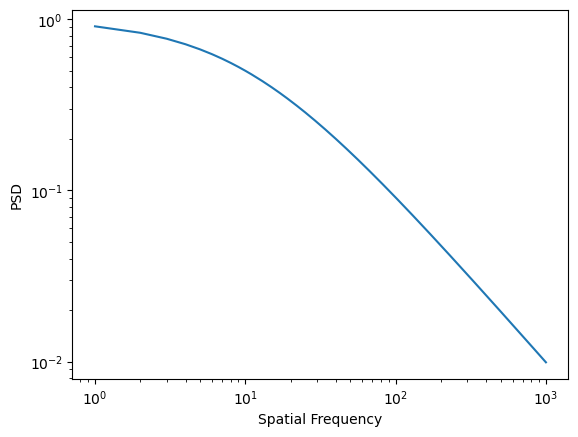

In [140]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

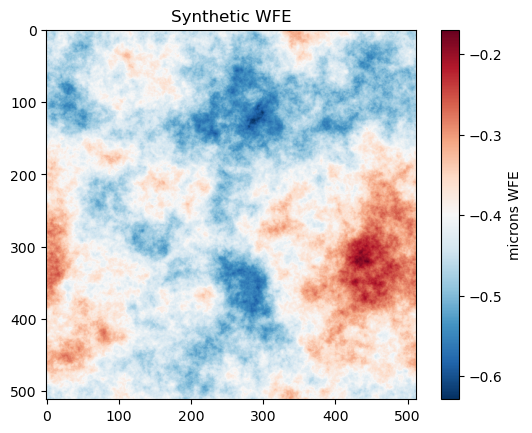

In [141]:
# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

## Configure Diffraction Model

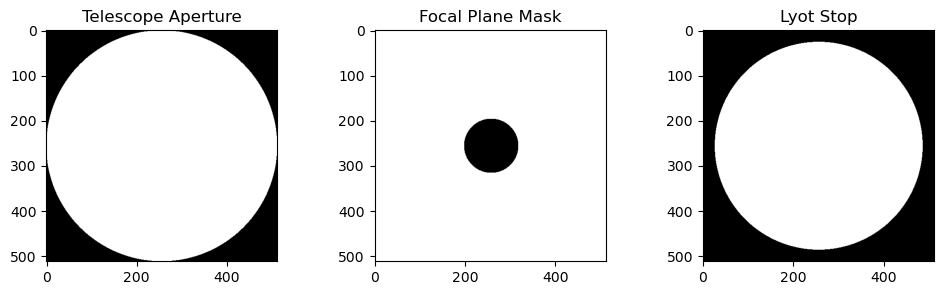

In [142]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[u < IWA] = 0

FPM = np.ones_like(u)
FPM[ rho < IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[12,3])
plt.subplot(131)
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.subplot(132)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.subplot(133)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.show()

In [143]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


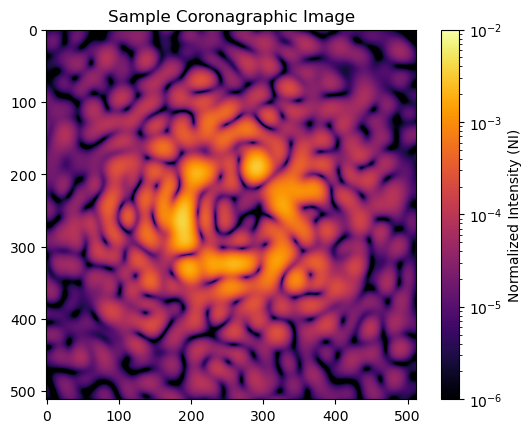

In [144]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Apply Waffle Pattern at maximum DM frequency

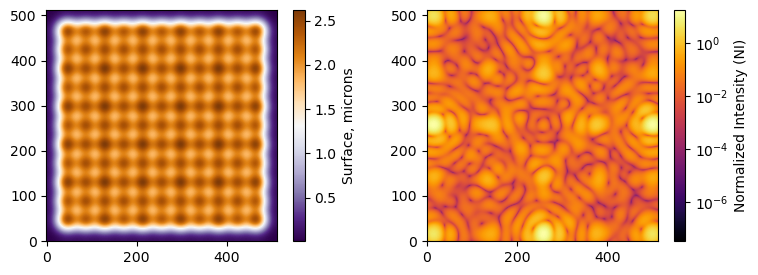

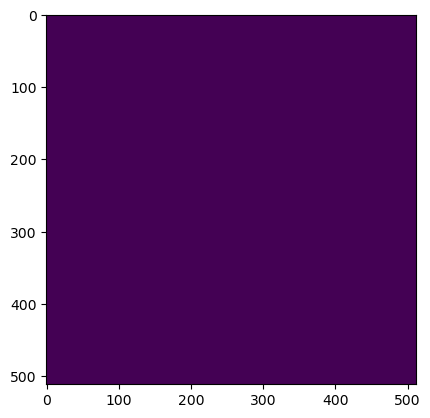

In [145]:
waffle = np.ones_like(dm.actuators) * 1e-1
for i in range(dm.actuators.shape[0]):
    for j in range(dm.actuators.shape[1]):

        if i%2 != 0 or j%2 != 0:
            waffle[i,j] = 0

dm.actuators[:] += waffle

plt.figure(figsize=[9,3])
plt.subplot(121)
plt.imshow(dm.render(), cmap="PuOr_r", origin="lower")
plt.colorbar(label="Surface, microns")
plt.subplot(122)
waffle_image = snap_image(dm.render(wfe=True))
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()
dm.actuators[:] -= waffle
dm.actuators[:] = 0
plt.imshow(dm.render())

# Configure Detector Quadrants

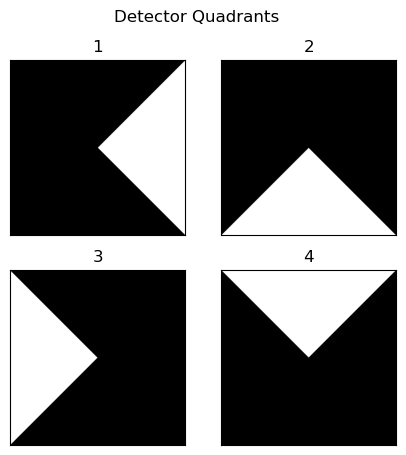

In [146]:
x, y = make_xy_grid(waffle_image.shape, diameter=1)

# set up diagonals
true_mask = np.zeros_like(A)
q1 = np.copy(true_mask)
q2 = np.copy(true_mask)
q3 = np.copy(true_mask)
q4 = np.copy(true_mask)

q1[(x > y) & (-x < y)] = 1
q2[(y > -x) & (x < y)] = 1
q3[(y > x) & (x < -y)] = 1
q4[(x > y) & (x < -y)] = 1

quarters = [q1, q2, q3, q4]
plt.figure(figsize=[5,5])
plt.suptitle("Detector Quadrants")
for i,q in enumerate(quarters):

    plt.subplot(2, 2, i+1)
    plt.title(f"{i+1}")
    plt.imshow(q, cmap="gray")
    plt.xticks([],[])
    plt.yticks([],[])

plt.show()

# Find the hotspot in each quadrant

In [147]:
def find_max_index(array):
    index = np.unravel_index(array.argmax(), array.shape)
    return index


def make_quadrant_masks(image):

    x, y = make_xy_grid(image.shape, diameter=1)

    # set up diagonals
    true_mask = np.zeros_like(image)
    q1 = np.copy(true_mask)
    q2 = np.copy(true_mask)
    q3 = np.copy(true_mask)
    q4 = np.copy(true_mask)

    q1[(x > y) & (-x < y)] = 1  # East
    q2[(y > -x) & (x < y)] = 1  # South
    q3[(y > x) & (x < -y)] = 1  # West
    q4[(x > y) & (x < -y)] = 1  # North

    return [q1, q2, q3, q4]


def find_cardinal_points(image):

    quads = make_quadrant_masks(image)
    coords = []

    for q in quads:

        row, col = find_max_index(q * image)
        coords.append((row, col))

    return coords


def find_image_center(image):

    # returns East, South, West, North
    coords = find_cardinal_points(image)
    row_center = 0
    col_center = 0

    for coord in coords:
        row_center += coord[0] / len(coords)
        col_center += coord[1] / len(coords)

    return row_center, col_center




coords = find_cardinal_points(waffle_image)
rowc, colc = find_image_center(waffle_image)
# draw a circle over it


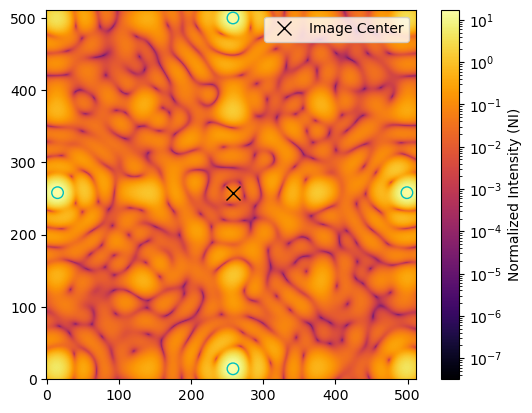

In [148]:
plt.figure()
plt.imshow(waffle_image, cmap="inferno", norm=LogNorm(), origin="lower")
plt.colorbar(label="Normalized Intensity (NI)")
ax = plt.gca()

# plot cardinal points
for coord in coords:
    row = coord[0]
    col = coord[1]
    max_circ = Circle((row, col), radius=4/dx_img, facecolor="None", edgecolor="c")
    ax.add_patch(max_circ)

# find image center
plt.plot(rowc, colc, marker="x", color="k", markersize=5/dx_img, label="Image Center", linestyle="None")
plt.legend()
plt.show()

# Empirically Compute Pixel scale in $\lambda / D$

Not 100% convinced I'm doing this right but probably fine for now yeah?

In [149]:
def compute_pixel_scale_lamd(image, waffle_frequency=5):

    rowc, colc = find_image_center(image)
    coords = find_cardinal_points(image)
    row_differences = []
    col_differences = []

    for coord in coords:
        row_differences.append((coord[0] - rowc)**2)
        col_differences.append((coord[1] - colc)**2)

    # average the pixelscale
    separations = np.sqrt(row_differences + col_differences)
    mean_separation = np.mean(separations) / waffle_frequency / 2 * np.pi

    return mean_separation

print(compute_pixel_scale_lamd(waffle_image, waffle_frequency=5),r"pix per $\lambda / D$")

# compute from information known about the system
dx_img_LD = dx_img * 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(1/dx_img_LD,r"pix per $\lambda / D$")

38.17035074111599 pix per $\lambda / D$
20.0 pix per $\lambda / D$


# Empirically Compute the MTF of the Coronagraph

In [150]:
frequencies = np.arange(IWA, OWA, 0.25)
amplitudes = [0.11 * i for i in range(1,10)]
udm, vdm = make_xy_grid(nact, diameter=1)
mtf = np.zeros([len(frequencies), len(amplitudes)])
sample_image = snap_image()
q1, _, _, _ = make_quadrant_masks(sample_image)
for i, f in enumerate(frequencies):
    for j, amp in enumerate(amplitudes):

        # construct a sinusoid
        cosinusoid = np.cos(2 * np.pi * udm * f) * amp
        dm.actuators[:] += cosinusoid
        
        # only look in the eastern quadrant
        img = snap_image(pupil_wfe=dm.render(wfe=True)) * q1
        mtf[i, j] = img.max()
        dm.actuators[:] -= cosinusoid


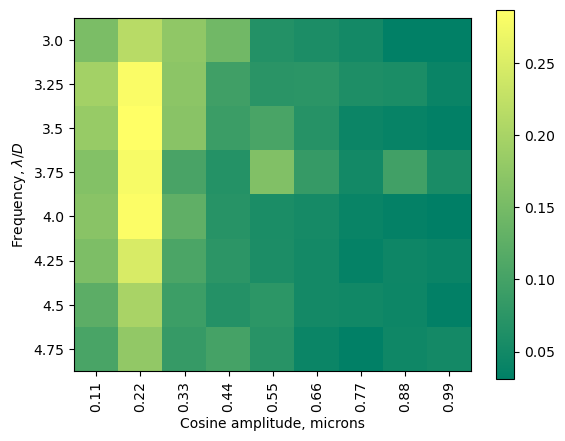

In [151]:
plt.imshow(mtf / ref_contrast, cmap="summer")
plt.xticks(np.arange(0, len(amplitudes), 1), amplitudes, rotation=90)
plt.yticks(np.arange(0, len(frequencies)), frequencies)
plt.ylabel("Frequency, "+r"$\lambda / D$")
plt.xlabel("Cosine amplitude, microns")
plt.colorbar()
plt.show()

## Create a Spline interpolating between the values
Kind of like a Jacobian actually haha

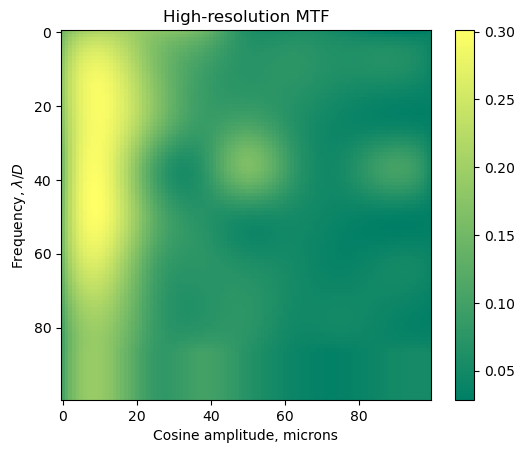

In [152]:
from scipy.interpolate import RectBivariateSpline

mtf_spline = RectBivariateSpline(frequencies, amplitudes, mtf)

# plot a higher-res spline
x = np.linspace(IWA, OWA, 100)
y = np.linspace(0.11, 0.99, 100)
mtf_hires = mtf_spline(x, y)

plt.title("High-resolution MTF")
plt.imshow(mtf_hires / ref_contrast, cmap="summer")
plt.colorbar()
plt.ylabel("Frequency, "+r"$\lambda / D$")
plt.xlabel("Cosine amplitude, microns")
plt.show()

# Select a bright speckle from the dark hole

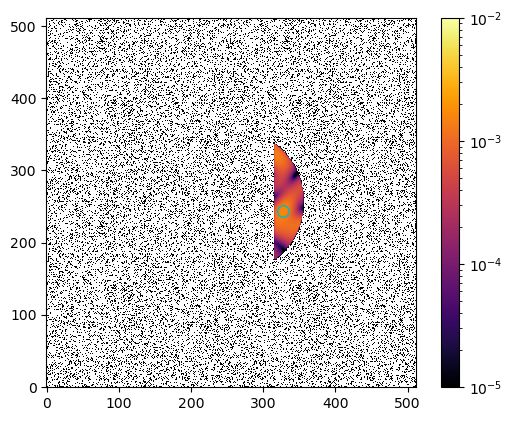

In [153]:
image_masked = snap_image() * dark_hole / ref_contrast
rowb, colb = find_max_index(image_masked)

plt.figure()
plt.imshow(image_masked, cmap="inferno", origin="lower", norm=LogNorm(vmax=1e-2,vmin=1e-5))
ax = plt.gca()
max_speckle = Circle((colb, rowb), radius=4/dx_img, facecolor="None", edgecolor="c")
ax.add_patch(max_speckle)
plt.colorbar()
plt.show()

# Probe the speckle

In [154]:
def get_speckle_correction(forward_model, dm, dark_hole, image_dx_lamD, nsteps=4, probe_amplitude=1e-3,
                           return_probe_images=False):
    # TODO: Implement amplitude correction

    # the probe offsets
    if nsteps == 4:
        probe_phases = [0, np.pi/2, np.pi, 3 * np.pi / 2]
    else:
        raise NotImplementedError
    
    probe_images = []
    
    # find location of max speckle in dark_hole
    img = forward_model(dm.render(wfe=True)) * dark_hole
    img_max = img.max()
    rowmax, colmax = find_max_index(img)

    # convert to a frequency in the fourier domain
    rowc, colc = find_image_center(waffle_image)

    row_freq = (rowmax - rowc) * image_dx_lamD
    col_freq = (colmax - colc) * image_dx_lamD

    # construct the cosinusoid
    udm, vdm = make_xy_grid(nact, diameter=1)

    for probe in probe_phases:
        probe_speckle = np.cos(2 * np.pi * (udm * col_freq + vdm * row_freq) + probe) * probe_amplitude
        dm.actuators[:] += probe_speckle
        probe_image = forward_model(dm.render(wfe=True)) / ref_contrast
        probe_images.append(probe_image)
        dm.actuators[:] -= probe_speckle

    # phase unwrapping algorithm
    I1 = probe_images[0][rowmax, colmax]
    I2 = probe_images[1][rowmax, colmax]
    I3 = probe_images[2][rowmax, colmax]
    I4 = probe_images[3][rowmax, colmax]

    real = I1 - I3
    imag = I4 - I2
    phase = np.arctan2(imag, real)
    gain = 1
    amplitude = np.sqrt(real**2 + imag**2) * gain
    print(amplitude)

    # construct sinusoid with pi phase offset to cancel
    phase += np.pi # to cancel
    probe_speckle = np.cos(2 * np.pi * (udm * col_freq + vdm * row_freq) + phase)
    probe_speckle *= amplitude
    if return_probe_images:
        return probe_speckle, probe_images
    else:
        return probe_speckle


correction = get_speckle_correction(snap_image, dm, dark_hole=dark_hole, image_dx_lamD=dx_img_LD)

0.0006513180704716295


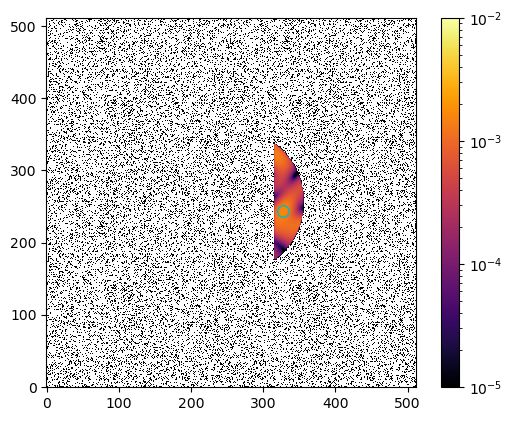

In [155]:
img_nulled = snap_image(dm.render(wfe=True))
image_masked = img_nulled * dark_hole / ref_contrast
rowb, colb = find_max_index(image_masked)

plt.figure()
plt.imshow(image_masked, cmap="inferno", origin="lower", norm=LogNorm(vmax=1e-2, vmin=1e-5))
ax = plt.gca()
max_speckle = Circle((colb, rowb), radius=4/dx_img, facecolor="None", edgecolor="c")
ax.add_patch(max_speckle)
plt.colorbar()
plt.show()

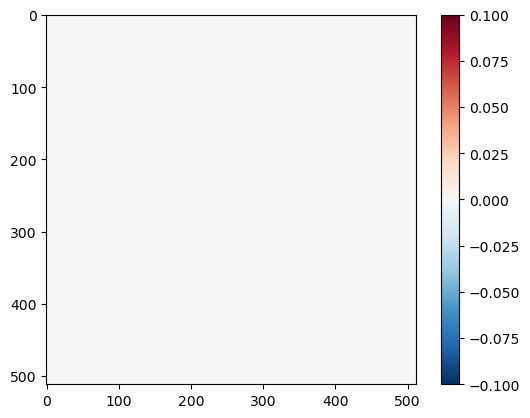

In [156]:
plt.imshow(dm.render(), cmap="RdBu_r")
plt.colorbar()

In [157]:
dm.actuators[:] += correction
img_nulled = snap_image(dm.render(wfe=True))

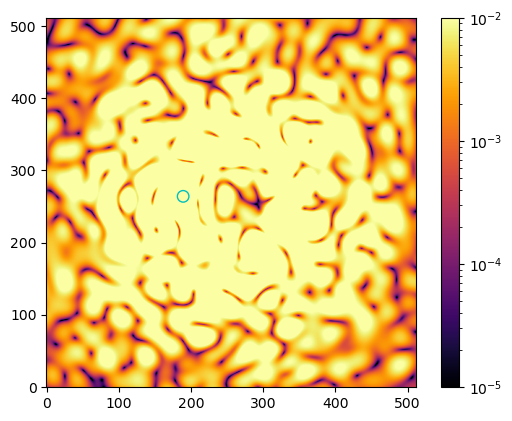

In [158]:
image_masked = img_nulled * ref_contrast / ref_contrast
rowb, colb = find_max_index(image_masked)

plt.figure()
plt.imshow(image_masked, cmap="inferno", origin="lower", norm=LogNorm(vmax=1e-2, vmin=1e-5))
ax = plt.gca()
max_speckle = Circle((colb, rowb), radius=4/dx_img, facecolor="None", edgecolor="c")
ax.add_patch(max_speckle)
plt.colorbar()
plt.show()

A SR > 1 indicates the wavefront quality got better


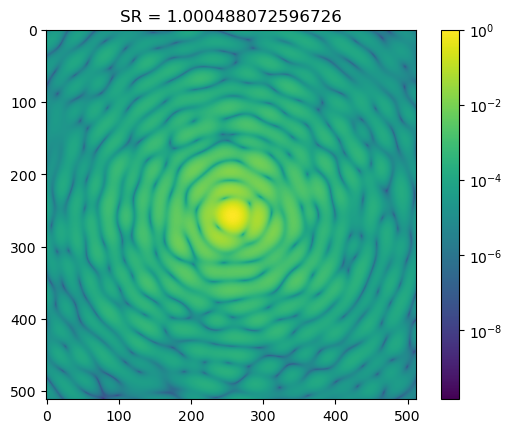

In [159]:
img_check = (snap_image(dm.render(wfe=True), include_fpm=False))

print("A SR > 1 indicates the wavefront quality got better")
plt.title(f"SR = {img_check.max() / ref_contrast}")
plt.imshow(img_check / ref_contrast, norm=LogNorm())
plt.colorbar()

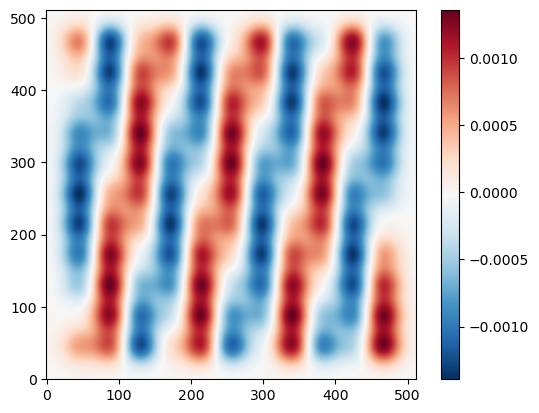

In [160]:
plt.imshow(dm.render(), cmap="RdBu_r", origin="lower")
plt.colorbar()

0.0006328766732280341


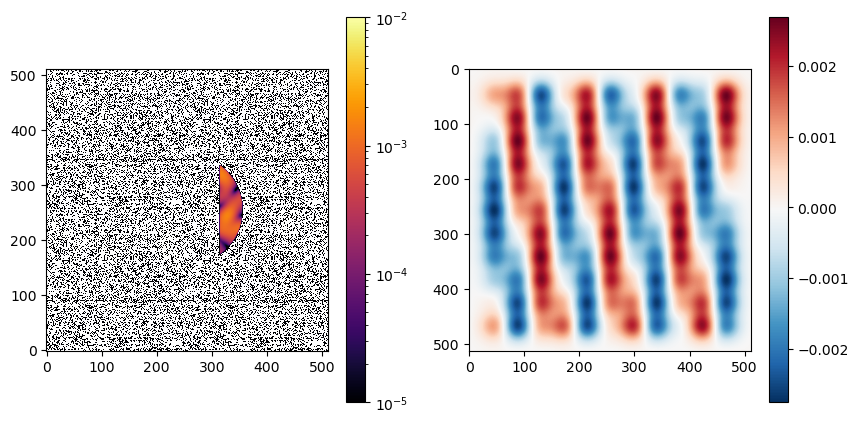

0.0006199046536189954


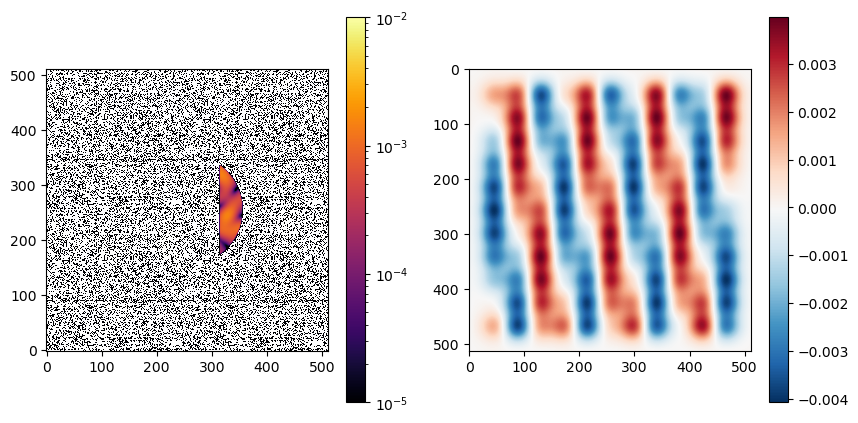

0.0006135263403639491


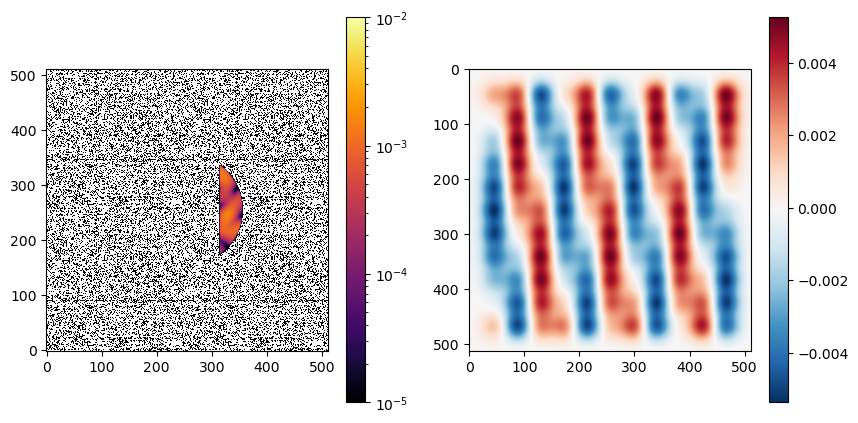

0.000611102196301419


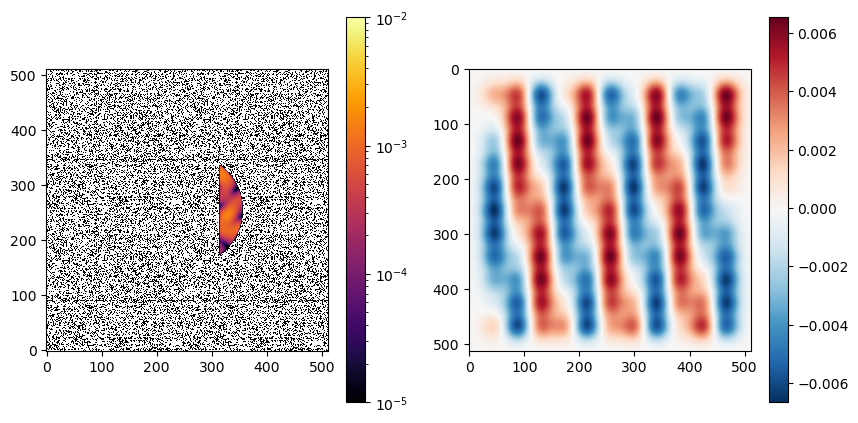

0.0006168783820624518


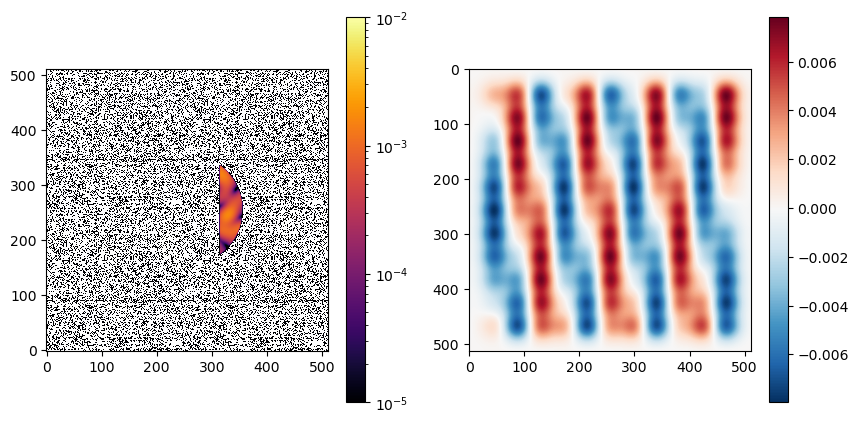

In [161]:
MAX_ITER = 5
PLOT_INTERMEDIATES = True
images_sn = []
for i in range(MAX_ITER):

    # get the correction
    correction = get_speckle_correction(snap_image, dm, dark_hole=dark_hole, image_dx_lamD=dx_img_LD)
    dm.actuators[:] += correction
    img_nulled = snap_image(dm.render(wfe=True)) / ref_contrast
    images_sn.append(img_nulled)


    # make a pretty plot
    if PLOT_INTERMEDIATES:

        plt.figure(figsize=[10, 5])
        plt.subplot(121)
        plt.imshow(img_nulled * dark_hole, cmap="inferno", origin="lower", norm=LogNorm(vmax=1e-2, vmin=1e-5))
        plt.colorbar()
        plt.subplot(122)
        plt.imshow(dm.render(), cmap="RdBu_r")
        plt.colorbar()
        plt.show()
    

In [162]:
correction, imgs = get_speckle_correction(snap_image, dm, dark_hole=dark_hole, image_dx_lamD=dx_img_LD, return_probe_images=True, probe_amplitude=1e-2)
dm.actuators[:] += correction
img_nulled = snap_image(dm.render(wfe=True)) / ref_contrast
imgs.append(img_nulled)

0.006259911221280173


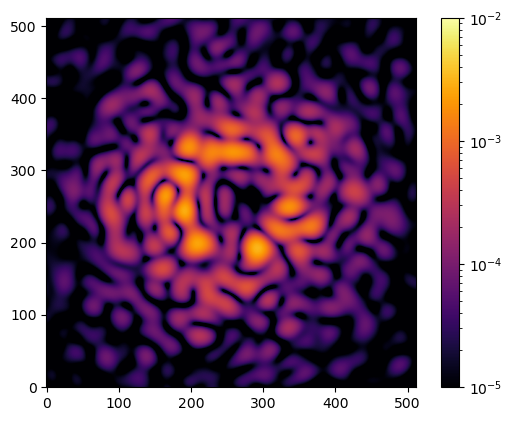

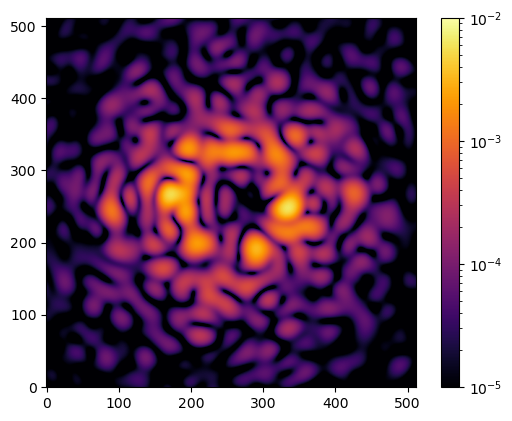

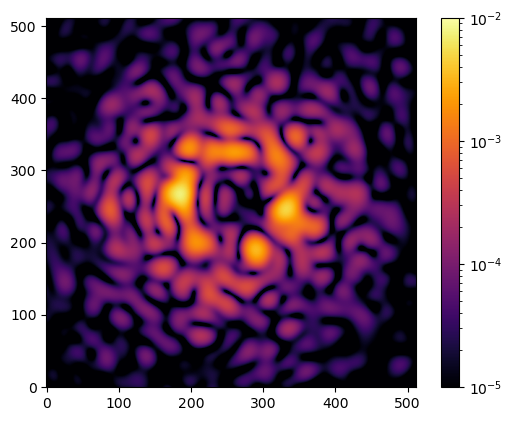

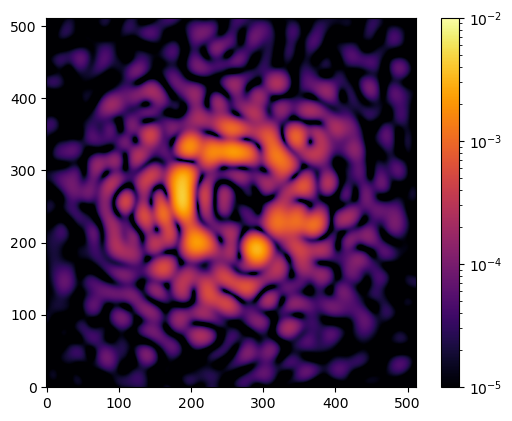

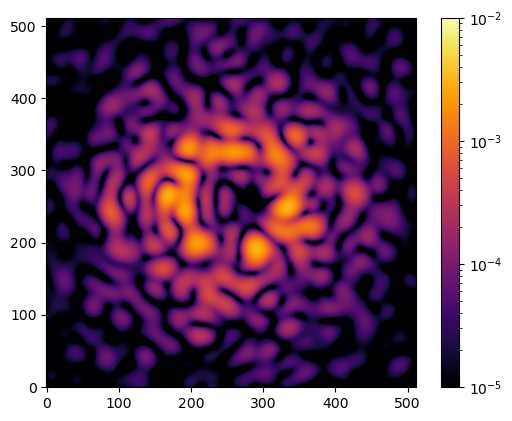

In [163]:
for im in imgs:
    plt.figure()
    plt.imshow(im, cmap="inferno", origin="lower", norm=LogNorm(vmax=1e-2, vmin=1e-5))
    plt.colorbar()
    plt.show()